##Step 2: Data Collection

###Import Libraries

In [ ]:
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split,KFold,cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,precision_score,recall_score,roc_curve,roc_auc_score,confusion_matrix,classification_report
import warnings
warnings.filterwarnings('ignore')

###Load Dataset

In [ ]:
wine_data = load_wine()
wine_data

{'data': array([[1.423e+01, 1.710e+00, 2.430e+00, ..., 1.040e+00, 3.920e+00,
         1.065e+03],
        [1.320e+01, 1.780e+00, 2.140e+00, ..., 1.050e+00, 3.400e+00,
         1.050e+03],
        [1.316e+01, 2.360e+00, 2.670e+00, ..., 1.030e+00, 3.170e+00,
         1.185e+03],
        ...,
        [1.327e+01, 4.280e+00, 2.260e+00, ..., 5.900e-01, 1.560e+00,
         8.350e+02],
        [1.317e+01, 2.590e+00, 2.370e+00, ..., 6.000e-01, 1.620e+00,
         8.400e+02],
        [1.413e+01, 4.100e+00, 2.740e+00, ..., 6.100e-01, 1.600e+00,
         5.600e+02]]),
 'target': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1

In [ ]:
wine_data_df = pd.DataFrame(wine_data.data,columns=wine_data.feature_names)
wine_data_df

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740.0
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0


##Step 3: Data Understanding

###Perform Initial Investigation

In [ ]:
wine_data_df.shape

(178, 13)

In [ ]:
wine_data_df.isna().sum()

,0
alcohol,0
malic_acid,0
ash,0
alcalinity_of_ash,0
magnesium,0
total_phenols,0
flavanoids,0
nonflavanoid_phenols,0
proanthocyanins,0
color_intensity,0


In [ ]:
wine_data_df.dtypes

,0
alcohol,float64
malic_acid,float64
ash,float64
alcalinity_of_ash,float64
magnesium,float64
total_phenols,float64
flavanoids,float64
nonflavanoid_phenols,float64
proanthocyanins,float64
color_intensity,float64


In [ ]:
wine_data_df.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


##Step 4: Data Preparation

In [ ]:
wine_data_df['target'] = wine_data.target

In [ ]:
X = wine_data_df.drop(columns='target')
X

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740.0
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0


In [ ]:
y = wine_data_df['target']
y

,target
0,0
1,0
2,0
3,0
4,0
...,...
173,2
174,2
175,2
176,2


#### Applying StandardScaler on the input feature

In [ ]:
std_scaler = StandardScaler()
Scaled_X = std_scaler.fit_transform(X)
pd.DataFrame(Scaled_X, columns=wine_data.feature_names)

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,1.518613,-0.562250,0.232053,-1.169593,1.913905,0.808997,1.034819,-0.659563,1.224884,0.251717,0.362177,1.847920,1.013009
1,0.246290,-0.499413,-0.827996,-2.490847,0.018145,0.568648,0.733629,-0.820719,-0.544721,-0.293321,0.406051,1.113449,0.965242
2,0.196879,0.021231,1.109334,-0.268738,0.088358,0.808997,1.215533,-0.498407,2.135968,0.269020,0.318304,0.788587,1.395148
3,1.691550,-0.346811,0.487926,-0.809251,0.930918,2.491446,1.466525,-0.981875,1.032155,1.186068,-0.427544,1.184071,2.334574
4,0.295700,0.227694,1.840403,0.451946,1.281985,0.808997,0.663351,0.226796,0.401404,-0.319276,0.362177,0.449601,-0.037874
...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,0.876275,2.974543,0.305159,0.301803,-0.332922,-0.985614,-1.424900,1.274310,-0.930179,1.142811,-1.392758,-1.231206,-0.021952
174,0.493343,1.412609,0.414820,1.052516,0.158572,-0.793334,-1.284344,0.549108,-0.316950,0.969783,-1.129518,-1.485445,0.009893
175,0.332758,1.744744,-0.389355,0.151661,1.422412,-1.129824,-1.344582,0.549108,-0.422075,2.224236,-1.612125,-1.485445,0.280575
176,0.209232,0.227694,0.012732,0.151661,1.422412,-1.033684,-1.354622,1.354888,-0.229346,1.834923,-1.568252,-1.400699,0.296498


##Step 5: Model Building

###Train Test Split

In [ ]:
X_train,X_test,y_train,y_test = train_test_split( Scaled_X, y, test_size=0.2,random_state=13,shuffle=True,stratify=y)

In [ ]:
X_train.shape,y_train.shape

((142, 13), (142,))

In [ ]:
X_test.shape,y_test.shape

((36, 13), (36,))

###Model Initialization

In [ ]:
knn_classifier = KNeighborsClassifier(n_neighbors=19)

In [ ]:
cv_score_mean = []
kfold =KFold(n_splits=5,shuffle=True,random_state=13)
for i in range(3,51,2):
  knn_classifier_1 = KNeighborsClassifier(n_neighbors=i)
  knn_classifier_1.fit(X_train,y_train)
  cv_score =cross_val_score(estimator=knn_classifier_1,X=X_train,y=y_train,cv=kfold)
  print(cv_score)
  cv_score_mean.append(cv_score.mean().round(4))

[0.96551724 0.93103448 0.89285714 0.92857143 0.92857143]
[1.         0.93103448 0.89285714 1.         0.96428571]
[1.         0.93103448 0.89285714 0.96428571 0.96428571]
[1.         0.93103448 0.89285714 1.         0.96428571]
[1.         0.96551724 0.92857143 1.         0.92857143]
[1.         0.96551724 0.92857143 1.         0.92857143]
[1.         0.96551724 0.92857143 1.         0.96428571]
[1.         0.96551724 0.92857143 1.         0.96428571]
[1.         1.         0.96428571 0.96428571 0.96428571]
[1.         1.         0.96428571 0.96428571 0.92857143]
[1.         1.         0.96428571 0.96428571 0.96428571]
[1.         1.         0.96428571 0.96428571 0.96428571]
[1.         0.96551724 0.92857143 0.96428571 0.96428571]
[1.         0.96551724 0.96428571 0.92857143 0.92857143]
[1.         1.         0.96428571 0.92857143 0.92857143]
[1.         0.96551724 0.96428571 0.92857143 0.92857143]
[1.         0.93103448 0.96428571 0.92857143 0.92857143]
[1.         0.93103448 0.964285

In [ ]:
max(cv_score_mean)

np.float64(0.9786)

In [ ]:
cv_score_mean.index(max(cv_score_mean))

8

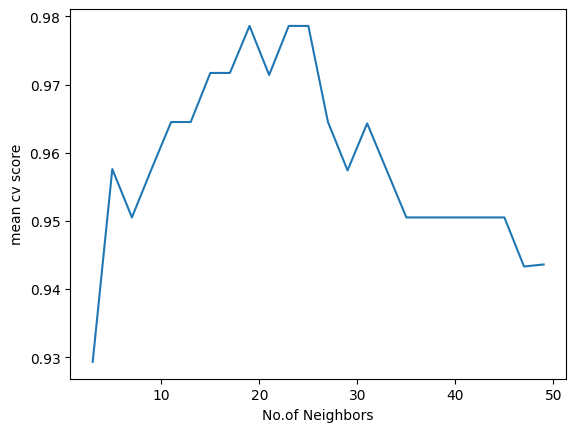

In [ ]:
plt.plot(range(3,51,2),cv_score_mean)
plt.xlabel('No.of Neighbors')
plt.ylabel('mean cv score')
plt.show()

##Step 6: Model Training

In [ ]:
knn_classifier.fit(X_train,y_train)

KNeighborsClassifier(n_neighbors=19)

##Step 7: Model Testing

###Training Data Prediction

In [ ]:
y_pred_train = knn_classifier.predict(X_train)

###Test Data Prediction

In [ ]:
y_pred_test = knn_classifier.predict(X_test)

##Step 8: Model Evaluation

###Training Data Evaluation

In [ ]:
print('Train Data Accuracy:',accuracy_score(y_train,y_pred_train))
print('Train Data Precision:',precision_score(y_train,y_pred_train, average='weighted'))
print('Train Data Recall:',recall_score(y_train,y_pred_train,average='weighted'))
print('Confusion_matrix:\n',confusion_matrix(y_train,y_pred_train))

Train Data Accuracy: 0.9788732394366197
Train Data Precision: 0.9797241784037559
Train Data Recall: 0.9788732394366197
Confusion_matrix:
 [[47  0  0]
 [ 1 54  2]
 [ 0  0 38]]


###Test Data Evaluation

In [ ]:
print('Train Data Accuracy:',accuracy_score(y_test,y_pred_test))
print('Train Data Precision:',precision_score(y_test,y_pred_test,average='weighted'))
print('Test Data Recall:',recall_score(y_test,y_pred_test,average='weighted'))

Train Data Accuracy: 0.9722222222222222
Train Data Precision: 0.9743589743589745
Test Data Recall: 0.9722222222222222
